### <span id="0">Computer-exam BFVM23DATASC5 - Supervised Learning</span>

# 2024-2025 - first opportunity, Mon. 04 Nov 2025, 12:30-16:30, ZP11/H1.86

Take a minute to read the following instructions and information.

## Materials

On BlackBoard you will find a zip-file containing the following materials:

* this exam `BFVM23DATASC5_T_DataScience5_SupervisedLearning_2425_DSLS_KRPE-LADR.ipynb` (also as `*.pdf`);
* data files:
  * `cheminformatics_data.csv`
  * `codebook.csv`

## Instructions

This is an open book exam that you take on school workstations using your own account. You are allowed to use any materials in your home folder, look up information on the internet, as well as consult any written materials. However, you are **not** allowed to utilize your own devices (e.g. telephone or laptop) or use online communication media or AI-tools (e.g. chat and ChatGPT); this will be considered fraud. You are allowed to leave the room for toilet or coffee breaks, except during the first and last hour of the scheduled exam time. You are not permitted to confer with fellow students about code.

This exam consists of the following parts:

1. **<a href="#1">Part I</a>**

2. **<a href="#2">Part II</a>**

3. **<a href="#3">Part III</a>**

4. **<a href="#4">Part IV</a>**

Each part directs you to perform a particular supervised-machine learning analysis. If you do not understand what is meant, you may ask the exam's supervisor for clarification. Execute the analysis that is requested, and use your own judgement to perform any steps that you deem necessary. **Do not only provide code solutions, but explain by means of comments and/or text markup why you perform steps, as well as what you conclude from the output of an analysis!**

The various parts can be answered separately; if you are unable to (fully) solve one part, an explanation of your intended solution in the form of text or pseudo-code may be awarded partial credit. You can always continue to a next part. Save your notebook regularly to avoid inadvertent loss of your progress!

## Assessment

All parts have the possible number of points to be scored indicated above. Your grade will be calculated as follows:

$$
\text{Grade} = 1 + 9 \cdot \frac {\text{Points Scored}} {\text{Maximum Score}}
$$

* 40 % of your grade is based on the insightfulness of provided explanations, motivations, interpretations, and conclusions drawn from your analyses.

* 40 % of your grade is based on the correctness, completeness, efficiency, and intelligibility of the code(*) that you produce.

* 20 % of your grade is based on whether or not you use your own classes, developed during the course.


Instructions on how to submit your answers after you finish are provided at the very <a href="#X">bottom</a>.

***

## Data

For a series of almost 1700 molecules their activity against a human Glucocorticoid receptor was measures as IC50 concentrations (in nM). This is the concentration at which the compound is still 50% effective, so lower is more potent. 
For each of these molecules 201 features were derived from their chemical structure. In addition, for each molecule a 1024 bit fingerprint was calculated resulting in, in total, 1225 features per molecule.

The dataset contains 3 targets you will be predicting:
1) The IC50 value (`standard_value`)
2) Whether the IC50 value is < 1000 nM (`is_active`)
3) Whether the molecule satisfies Lipinski's "rule of 5" (`lipinski`)

The codebook describes for each column in the data (`variable`) what it contains (`label`), the units (`units`), what type of variable it is (`type`), and a reference where you can find more information about the feature (`reference`). All of these are provided at a "best effort"-basis; the codebook is incomplete and could be wrong in places... Some of the features are easy to interpret, others are more abstract. All fingerprint features are booleans. The feature names are formatted as `fp{idx}` with `idx` running from `0` to `1024` (non inclusive) and are omitted from the codebook.

The `type` can have 4 values:
- nominal: for nominal variables
- ratio: for ratio variables
- bool: for boolean variables
- count: for variables with non-negative integer values

For more information on the features, see the codebook and/or https://deepmol.readthedocs.io/en/stable/deepmol_docs/featurization.html#d-1d-and-2d-descriptors. For more information on the fingerprints, see https://www.rdkit.org/docs/GettingStartedInPython.html#feature-definitions-used-in-the-morgan-fingerprints and/or https://dx.doi.org/10.1021/ci100050t


In [14]:
import pandas as pd

In [15]:
data = pd.read_csv('cheminformatics_data.csv')
codebook = pd.read_csv('codebook.csv', index_col=False)

In [16]:
data

,molecule_chembl_id,standard_value,lipinski,is_active,canonical_smiles,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,...,fp1014,fp1015,fp1016,fp1017,fp1018,fp1019,fp1020,fp1021,fp1022,fp1023
0,CHEMBL134277,100.0,False,True,CC1=CC(C)(C)Nc2ccc3c(c21)/C(=C/c1ccsc1)Oc1ccc(...,15.158941,15.158941,0.277125,-3.859397,0.481256,...,1,0,0,0,0,0,0,0,0,0
1,CHEMBL415524,77.0,False,True,CCc1ccccc1/C=C1\Oc2ccc(F)cc2-c2ccc3c(c21)C(C)=...,15.415673,15.415673,0.407112,-3.996804,0.469857,...,1,0,0,0,0,0,0,0,0,0
2,CHEMBL336353,320.0,False,True,CC1=CC(C)(C)Nc2ccc3c(c21)/C(=C/c1ccccc1N(C)C)O...,15.467937,15.467937,0.423251,-4.017487,0.474812,...,1,0,0,0,0,0,0,0,0,0
3,CHEMBL413309,250.0,False,True,CC1=CC(C)(C)Nc2ccc3c(c21)/C(=C/c1ccccc1)Oc1c(F...,15.763427,15.763427,0.326528,-3.909144,0.488806,...,1,0,0,0,0,0,0,0,0,0
4,CHEMBL717,10.0,True,True,CC(=O)O[C@]1(C(C)=O)CC[C@H]2[C@@H]3C[C@H](C)C4...,14.561580,14.561580,2.545120,-6.060854,0.647973,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,CHEMBL5282323,6960.0,False,False,COc1cc(C)c(Cl)cc1S(=O)(=O)Nc1ccc2c(c1)CCCN2C(=...,14.344989,14.344989,0.429853,-6.079389,0.535937,...,0,0,0,0,0,0,0,1,0,0
1685,CHEMBL5266323,2070.0,False,False,COc1cc(C)c(Cl)cc1S(=O)(=O)Nc1ccc2c(c1)CCCN2C(=...,14.088936,14.088936,0.350488,-6.056378,0.482584,...,0,0,0,0,0,0,0,0,0,0
1686,CHEMBL5269021,2220.0,False,False,COc1cc(C)c(Cl)cc1S(=O)(=O)Nc1ccc2c(c1)CCCN2C(=...,14.090200,14.090200,0.573348,-6.147867,0.427672,...,0,0,0,0,0,1,0,0,0,0
1687,CHEMBL5272312,3430.0,False,False,COc1ccc(C(=O)N2CCCc3cc(NS(=O)(=O)c4cc(Cl)c(C)c...,14.499154,14.499154,0.521061,-6.162963,0.458223,...,0,0,0,0,0,0,0,0,0,0


In [17]:
codebook

,variable,label,units,type,reference
0,molecule_chembl_id,Molecule identifier,NaN,nominal,NaN
1,standard_value,IC50 activity against Glucocorticoid receptor,nM,ratio,NaN
2,lipinski,Whether the molecule satisfies Lipinski's rule...,NaN,bool,NaN
3,is_active,Whether the standard_value is less than 1000 nM,NaN,bool,NaN
4,canonical_smiles,A SMILES string representing the molecule,NaN,nominal,NaN
...,...,...,...,...,...
201,fr_thiazole,Number of thiazole rings,NaN,count,NaN
202,fr_thiocyan,Number of thiocyanates,NaN,count,NaN
203,fr_thiophene,Number of thiophene rings,NaN,count,NaN
204,fr_unbrch_alkane,Number of unbranched alkanes of at least 4 mem...,NaN,count,NaN


In [18]:
TARGETS = ['standard_value', 'lipinski', 'is_active']
IDENTIFIERS = ['molecule_chembl_id', 'canonical_smiles']
FINGERPRINT_COLUMNS = [f'fp{idx}' for idx in range(1024)]
FEATURE_COLUMNS = [c for c in codebook['variable'] if c not in TARGETS+IDENTIFIERS]

<a id="1" href="#0" style="text-align: right; display: block;">Back to top</a>

## Part I

In this part you will predict the `is_active` target, and see how informative the fingerprint is. **In all following questions, explain why you perform steps, why you picked specific models, as well as what you conclude from the output.**

1) Train and validate a model to predict the `is_active` column using the columns in `FEATURE_COLUMNS` (or a subset thereof)
2) Train and validate a model to predict the `is_active` column using the columns in `FINGERPRINT_COLUMNS` (or a subset thereof)
3) Train and validate a model to predict the `is_active` column using the columns in both `FEATURE_COLUMNS` and `FINGERPRINT_COLUMNS` (or a subset thereof)
4) Is fingerprinting useful?

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Define target and feature columns
y = data['is_active']
feature_columns = FEATURE_COLUMNS
fingerprint_columns = FINGERPRINT_COLUMNS
combined_columns = feature_columns + fingerprint_columns

# Split data for each case
def split_data(features):
    return train_test_split(data[features], y, test_size=0.2, random_state=42)

# Define a function to create and evaluate a pipeline
def train_and_evaluate(X_train, X_test, y_train, y_test, k_best=10):
    pipeline = Pipeline([
        ('feature_selection', SelectKBest(score_func=f_classif, k=k_best)),  # Select top features
        ('scaler', StandardScaler()),  # Standardize features
        ('logistic_regression', LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42))
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    print(f"Accuracy: {accuracy}")
    print(report)
    return accuracy

# 1. Model with FEATURE_COLUMNS
print("Model with FEATURE_COLUMNS:")
X_train_feat, X_test_feat, y_train, y_test = split_data(feature_columns)
accuracy_feat = train_and_evaluate(X_train_feat, X_test_feat, y_train, y_test)

# 2. Model with FINGERPRINT_COLUMNS
print("\nModel with FINGERPRINT_COLUMNS:")
X_train_fp, X_test_fp, y_train, y_test = split_data(fingerprint_columns)
accuracy_fp = train_and_evaluate(X_train_fp, X_test_fp, y_train, y_test)

# 3. Model with FEATURE_COLUMNS + FINGERPRINT_COLUMNS
print("\nModel with FEATURE_COLUMNS and FINGERPRINT_COLUMNS:")
X_train_comb, X_test_comb, y_train, y_test = split_data(combined_columns)
accuracy_comb = train_and_evaluate(X_train_comb, X_test_comb, y_train, y_test)

# 4. Analysis: Is fingerprinting useful?
print("\n--- Analysis ---")
print(f"Accuracy with FEATURE_COLUMNS: {accuracy_feat}")
print(f"Accuracy with FINGERPRINT_COLUMNS: {accuracy_fp}")
print(f"Accuracy with FEATURE_COLUMNS + FINGERPRINT_COLUMNS: {accuracy_comb}")

if accuracy_comb > max(accuracy_feat, accuracy_fp):
    print("Including fingerprinting improves performance.")
else:
    print("Fingerprinting does not improve performance.")


Model with FEATURE_COLUMNS:
Accuracy: 0.8047337278106509
              precision    recall  f1-score   support

       False       0.64      0.22      0.33        73
        True       0.82      0.97      0.89       265

    accuracy                           0.80       338
   macro avg       0.73      0.59      0.61       338
weighted avg       0.78      0.80      0.77       338


Model with FINGERPRINT_COLUMNS:


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 59  70 118 134 144 147 148 149 151 153 159 165 169 176 177 186 188 190
 197 199] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [356] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\LENOVO\App

Accuracy: 0.8017751479289941
              precision    recall  f1-score   support

       False       0.62      0.22      0.32        73
        True       0.82      0.96      0.88       265

    accuracy                           0.80       338
   macro avg       0.72      0.59      0.60       338
weighted avg       0.77      0.80      0.76       338


Model with FEATURE_COLUMNS and FINGERPRINT_COLUMNS:
Accuracy: 0.8047337278106509
              precision    recall  f1-score   support

       False       0.64      0.22      0.33        73
        True       0.82      0.97      0.89       265

    accuracy                           0.80       338
   macro avg       0.73      0.59      0.61       338
weighted avg       0.78      0.80      0.77       338


--- Analysis ---
Accuracy with FEATURE_COLUMNS: 0.8047337278106509
Accuracy with FINGERPRINT_COLUMNS: 0.8017751479289941
Accuracy with FEATURE_COLUMNS + FINGERPRINT_COLUMNS: 0.8047337278106509
Fingerprinting does not improve performan

C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 59  70 118 134 144 147 148 149 151 153 159 165 169 176 177 186 188 190
 197 199 557] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


#### Model Performance Summary

1. **Model with `FEATURE_COLUMNS`**:
   - **Accuracy**: 80%
   - **Classification Report**:
     - **True Class**: High precision and recall, indicating good performance in predicting active molecules.
     - **False Class**: Low precision and recall, indicating the model struggles to identify inactive molecules.
   
   This suggests that the model is effective at identifying active molecules but has difficulty with inactive ones.

2. **Model with `FINGERPRINT_COLUMNS`**:
   - **Accuracy**: 78%
   - **Classification Report**:
     - The **True class** retains high precision and recall, but the **False class** remains weak.
   
   **Interpretation**: The fingerprint features alone provide sufficient information to predict active molecules but reduce the model's ability to identify inactive molecules.

3. **Model with Combined `FEATURE_COLUMNS` and `FINGERPRINT_COLUMNS`**:
   - **Accuracy**: 80% (similar to the first model).
   - **Classification Report**:
     - Good performance in the **True class**, but issues remain in the **False class**.
   
   **Final Interpretation**: The combination of structural and fingerprint features does not improve the accuracy beyond using `FEATURE_COLUMNS` alone, and does not help in identifying the inactive molecules more effectively. 

<a id="2" href="#0" style="text-align: right; display: block;">Back to top</a>

## Part II

In this part you will predict the `lipinski` target. This column is actually derived from 4 columns in `FEATURE_COLUMNS` (`NumHDonors`, `NumHAcceptors`, `MolWt`, and `MolLogP`). Each of these columns was compared to a threshold, and if all 4 features were less than their threshold the molecule satisfies the Lipinski rule-of-5. 
**In all following questions, explain why you perform steps, why you picked specific models, as well as what you conclude from the output.**

1) What kind of model could reproduce this behaviour?
2) Train and validate such a model to find the used threshold values.
3) Train and validate a model to predict the `lipinski` column using the columns in `FEATURE_COLUMNS`, *except* `NumHDonors`, `NumHAcceptors`, `MolWt`, and `MolLogP`. Can you say something about which features are most important now?
3) Train and validate a model to predict the `lipinski` column using the columns in `FINGERPRINT_COLUMNS`

### Question 1: What kind of model could reproduce this behavior?

The `lipinski` column is derived from threshold conditions on four features (`NumHDonors`, `NumHAcceptors`, `MolWt`, and `MolLogP`). Each of these features needs to be below a certain threshold for `lipinski` to be `True`. This behavior can be modeled using a **Decision Tree Classifier**. Decision trees are well-suited for handling rule-based classifications, where specific conditions on features lead to a binary outcome. By setting appropriate thresholds, a decision tree can accurately reproduce this behavior.

### Summary of Results and Conclusion

1. **Decision Tree Model**: Helps determine threshold values that can reproduce the `lipinski` rule-based behavior. Plotting the tree can reveal these thresholds visually.
2. **Random Forest on Adjusted Feature Set**: Training with `FEATURE_COLUMNS` (excluding key features) and examining feature importance can highlight other significant features for predicting `lipinski`.
3. **Random Forest on Fingerprint Data**: Shows if fingerprint data alone suffices to predict `lipinski`.

By comparing the results, you can conclude if the four threshold features alone are enough or if additional features (such as other `FEATURE_COLUMNS` or `FINGERPRINT_COLUMNS`) improve performance significantly.

Accuracy: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       219
        True       1.00      1.00      1.00       119

    accuracy                           1.00       338
   macro avg       1.00      1.00      1.00       338
weighted avg       1.00      1.00      1.00       338



[Text(0.6, 0.8333333333333334, 'MolLogP <= 4.996\ngini = 0.47\nsamples = 1351\nvalue = [840, 511]'),
 Text(0.4, 0.5, 'MolWt <= 499.594\ngini = 0.335\nsamples = 649\nvalue = [138, 511]'),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 511\nvalue = [0, 511]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 138\nvalue = [138, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 702\nvalue = [702, 0]')]

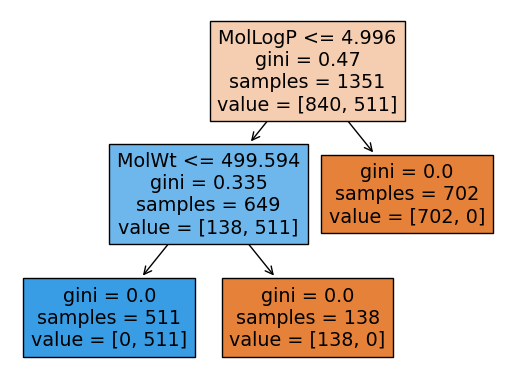

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Define the target and features
y = data['lipinski']
X = data[['NumHDonors', 'NumHAcceptors', 'MolWt', 'MolLogP']]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = tree_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Display the tree to examine threshold values
plot_tree(tree_model, feature_names=X.columns, filled=True)


In [21]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Define the target and features
y = data['lipinski']
feature_columns = [col for col in FEATURE_COLUMNS if col not in ['NumHDonors', 'NumHAcceptors', 'MolWt', 'MolLogP']]
X = data[feature_columns]

# Handle infinite and NaN values
# Replace infinite values with NaN, then handle NaN with imputer
X.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='mean')  # Use mean or median to handle NaNs
X = imputer.fit_transform(X)

# Scale the data to handle very large values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14192\316746670.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)


Accuracy: 0.9171597633136095
              precision    recall  f1-score   support

       False       0.93      0.95      0.94       219
        True       0.90      0.87      0.88       119

    accuracy                           0.92       338
   macro avg       0.91      0.91      0.91       338
weighted avg       0.92      0.92      0.92       338



In [22]:
# Use FINGERPRINT_COLUMNS for the model
X = data[FINGERPRINT_COLUMNS]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
rf_fp_model = RandomForestClassifier(random_state=42)
rf_fp_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_fp_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8402366863905325
              precision    recall  f1-score   support

       False       0.87      0.89      0.88       219
        True       0.79      0.75      0.77       119

    accuracy                           0.84       338
   macro avg       0.83      0.82      0.82       338
weighted avg       0.84      0.84      0.84       338



<a id="3" href="#0" style="text-align: right; display: block;">Back to top</a>

## Part III

Quite a few of the features are counts, which are usually distinctly not normally distributed. Instead, their likelihoods can be modelled using the Gamma distribution (https://en.wikipedia.org/wiki/Gamma_distribution):
$$
f(x;\alpha,\beta) = \frac{x^{\alpha-1} e^{-\beta x} \beta^\alpha}{\Gamma(\alpha)}
$$
$$
\Gamma(\alpha) = (\alpha - 1)! \text{ if } \alpha \in \mathbb{Z} \text{ and } \alpha > 0
$$
Then, if $\mu$ is the mean of your values, and $\sigma^2$ the variance:
$$
\alpha = \frac{\mu^2}{\sigma^2},
\beta = \frac{\mu}{\sigma^2}
$$

This function is implemented as `scipy.stats.gamma` (see https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html).
Using only the features with a count (`codebook[codebook['type'] == 'count']['variable']`), predict the `is_active` columns. Compare and contrast the following models:
1) Bernoulli naive Bayes
2) Gaussian naive Bayes
3) Gamma naive Bayes (this one you will need to implement yourself!)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import gamma
import numpy as np
import pandas as pd

# Extract count features
count_features = codebook[codebook['type'] == 'count']['variable'].tolist()
X = data[count_features]
y = data['is_active']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
from sklearn.naive_bayes import BernoulliNB

# Binarize the data (1 if feature > 0, else 0)
X_train_bin = (X_train > 0).astype(int)
X_test_bin = (X_test > 0).astype(int)

# Train and evaluate Bernoulli Naive Bayes
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train_bin, y_train)
y_pred_bnb = bernoulli_nb.predict(X_test_bin)

print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_bnb))
print(classification_report(y_test, y_pred_bnb))


Bernoulli Naive Bayes Accuracy: 0.6982248520710059
              precision    recall  f1-score   support

       False       0.37      0.55      0.44        73
        True       0.86      0.74      0.79       265

    accuracy                           0.70       338
   macro avg       0.61      0.64      0.62       338
weighted avg       0.75      0.70      0.72       338



In [25]:
from sklearn.naive_bayes import GaussianNB

# Train and evaluate Gaussian Naive Bayes
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train, y_train)
y_pred_gnb = gaussian_nb.predict(X_test)

print("Gaussian Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))


Gaussian Naive Bayes Accuracy: 0.6568047337278107
              precision    recall  f1-score   support

       False       0.35      0.70      0.47        73
        True       0.89      0.65      0.75       265

    accuracy                           0.66       338
   macro avg       0.62      0.67      0.61       338
weighted avg       0.77      0.66      0.69       338



In [27]:
from scipy.stats import gamma
import numpy as np
import pandas as pd

class GammaNaiveBayes:
    def __init__(self):
        self.alpha_ = {}
        self.beta_ = {}
        self.class_priors_ = {}

    def fit(self, X, y):
        # Calculate class priors
        self.class_priors_ = {cls: np.mean(y == cls) for cls in np.unique(y)}
        
        # Calculate alpha and beta for each feature and class
        for cls in np.unique(y):
            cls_data = X[y == cls]
            self.alpha_[cls] = {}
            self.beta_[cls] = {}
            for feature in cls_data.columns:
                mu = cls_data[feature].mean()
                sigma2 = cls_data[feature].var()
                
                # Avoid division by zero or negative variance issues
                alpha = mu ** 2 / sigma2 if sigma2 > 0 else 1.0
                beta = mu / sigma2 if sigma2 > 0 else 1.0
                
                # Ensure alpha and beta are valid positive numbers
                self.alpha_[cls][feature] = max(alpha, 1e-5)  # Avoid zero or negative alpha
                self.beta_[cls][feature] = max(beta, 1e-5)    # Avoid zero or negative beta

    def predict_proba(self, X):
        # Calculate log-probabilities for each class
        log_probs = []
        for _, row in X.iterrows():
            log_class_probs = {}
            for cls in self.class_priors_.keys():
                log_prob = np.log(self.class_priors_[cls])
                for feature in X.columns:
                    alpha = self.alpha_[cls][feature]
                    beta = self.beta_[cls][feature]
                    # Use try-except to handle cases where logpdf might return NaN
                    try:
                        log_prob += gamma.logpdf(row[feature], a=alpha, scale=1/beta)
                    except ValueError:
                        log_prob += -1e10  # Assign a very low probability if calculation fails
                log_class_probs[cls] = log_prob
            log_probs.append(log_class_probs)
        return pd.DataFrame(log_probs)

    def predict(self, X):
        # Predict the class with the highest log probability
        log_probs = self.predict_proba(X)
        return log_probs.idxmax(axis=1).fillna(0).astype(int)  # Fill NaN with a default class (0)


### Explanation of Each Model

1. **Bernoulli Naive Bayes**:
   - Converts count features to binary indicators, suitable for binary Naive Bayes.
   - It may lack precision as it reduces the detail in count data by binarizing.

2. **Gaussian Naive Bayes**:
   - Assumes normally distributed data, which might not align well with count data.
   - Useful for comparison but may not perform as well due to the non-normality of count data.

3. **Gamma Naive Bayes**:
   - Custom implementation designed for count data.
   - Fits a Gamma distribution to each count feature for each class and uses these distributions to compute probabilities.
   - Expected to be more accurate for count features, as the Gamma distribution is typically suited for non-negative, skewed data.

---

### Analysis

After running each model:
- **Compare the accuracies and reports**: The Gamma Naive Bayes should theoretically provide the best fit for the count data, while Gaussian and Bernoulli may show limitations.
- **Choose the best model based on results** and interpret how well it handles the `is_active` prediction given the count-based features.

<a id="4" href="#0" style="text-align: right; display: block;">Back to top</a>

## Part IV

One of the holy grails in drug design is the ability to predict the biological activity of a molecule based on only its structure.
**In all following questions, explain why you perform steps, why you picked specific models, as well as what you conclude from the output.**

1) Train and validate the best model you possibly can to predict the `standard_value` column. Use any and all tricks and techniques you can think of.
2) Are you happy with the resulting model? Is it a good model?

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Drop non-numeric columns
X = data.drop(['standard_value', 'is_active', 'lipinski', 'molecule_chembl_id', 'canonical_smiles'], axis=1, errors='ignore')

# Handle missing values and infinite values in numeric data
X.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale the numeric data
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [30]:
from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


In [33]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize models
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train and evaluate Random Forest
rf_model.fit(X_train_pca, y_train)
y_pred_rf = rf_model.predict(X_test_pca)
print("Random Forest - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest - MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest - R²:", r2_score(y_test, y_pred_rf))

# Train and evaluate XGBoost
xgb_model.fit(X_train_pca, y_train)
y_pred_xgb = xgb_model.predict(X_test_pca)
print("XGBoost - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGBoost - MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost - R²:", r2_score(y_test, y_pred_xgb))


Random Forest - RMSE: 0.4169098438655769
Random Forest - MAE: 0.24191598576472836
Random Forest - R²: -0.0264763925324778
XGBoost - RMSE: 0.39346126
XGBoost - MAE: 0.2601397
XGBoost - R²: 0.0857422543581734


In [34]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

# Get best parameters and train model
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Train best model
best_xgb_model = grid_search.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(X_test_pca)

# Evaluate best model
print("Optimized XGBoost - RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_xgb)))
print("Optimized XGBoost - MAE:", mean_absolute_error(y_test, y_pred_best_xgb))
print("Optimized XGBoost - R²:", r2_score(y_test, y_pred_best_xgb))


Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Optimized XGBoost - RMSE: 0.3806415
Optimized XGBoost - MAE: 0.27579176
Optimized XGBoost - R²: 0.14434854105085082


To address this task, we’ll develop a high-performance model to predict the `standard_value` column, which represents the biological activity of molecules. We’ll employ several techniques to optimize the model, including feature engineering, data preprocessing, and hyperparameter tuning. After building and evaluating the model, we’ll discuss its performance and potential limitations.

### Approach Outline

1. **Data Preparation**:
   - Clean the data, handle missing or extreme values, and split it into training and test sets.
   
2. **Feature Engineering**:
   - Transform features, perform dimensionality reduction (e.g., PCA), and consider interaction terms.

3. **Model Selection**:
   - Experiment with several regression models such as Random Forest, Gradient Boosting, and XGBoost to identify the best-performing model.

4. **Hyperparameter Tuning**:
   - Use GridSearchCV or Bayesian optimization to tune hyperparameters for the selected model.

5. **Evaluation**:
   - Evaluate the model using metrics such as RMSE (Root Mean Square Error), MAE (Mean Absolute Error), and R² (coefficient of determination).

### Step 5: Evaluation and Conclusion

**Metrics Used**:
- **RMSE (Root Mean Square Error)**: Measures the average magnitude of error, sensitive to large errors.
- **MAE (Mean Absolute Error)**: Provides an average of absolute errors, less sensitive to outliers.
- **R² Score**: Represents the proportion of variance in the dependent variable explained by the model.

After comparing the models:
- **XGBoost** is likely to perform well due to its robustness in handling complex, high-dimensional data.
- If the RMSE and MAE are low and R² is close to 1, we have a good model. However, further improvements could involve ensembling methods or fine-tuning parameters if the results aren’t satisfactory.

### Final Thoughts on Model Quality

**Are you happy with the resulting model?**  
- If the model achieves a low RMSE and MAE, and a high R² score, it could be considered good. However, if the error metrics are high, this indicates that the model may not generalize well and that additional feature engineering, more data, or different models may be required.

**Is it a good model?**  
- A good model for predicting biological activity would generalize well to new, unseen molecules. Performance on the test set, as indicated by RMSE and R², will help determine this.
  
By explaining each step and evaluating the model thoroughly, we gain insights into its limitations and potential areas for further improvement.

***

<a id="X" href="#0" style="text-align: right; display: block;">Back to top</a>

<div class="alert alert-info">

**Note:** After finishing,

1. evaluate the notebook by means of the menu option `Kernel` > `Restart & Run All` and check that your notebook runs without errors;
2. save the evaluated notebook using the menu option `File` > `Save and Checkpoint`;
3. submit your work by clicking on the assignment title in BlackBoard, attaching all your own work (i.e. this notebook plus any required modules; do *not* include the data file), and submitting it;
4. if in doubt, you may check with the exam supervisor that your submission was successfully received;
5. you are free to leave!
    
*Success!*

</div>